In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

load the data

In [4]:
df=pd.read_csv('churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.shape

(7043, 21)

EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df=df.drop('customerID',axis=1)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


data preprocessing

In [11]:
df['Dependents'].value_counts()

,count
Dependents,
No,4933
Yes,2110


In [12]:
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

In [13]:

from sklearn.preprocessing import LabelEncoder

# Columns to label encode
label_columns = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'Churn'
]

# Create LabelEncoder object
le = LabelEncoder()

# Apply label encoding
for col in label_columns:
    df[col] = le.fit_transform(df[col])

# Check result
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,2,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,2,0,2,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,1,0,0,0,2,1,0,DSL,2,2,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,2,0,2,2,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [14]:

# Columns for One-Hot Encoding
onehot_columns = [
    'InternetService',
    'Contract',
    'PaymentMethod'
]

# Apply One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=onehot_columns,
    drop_first=True  # avoids dummy variable trap
)

# Check result
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,2,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,2,0,2,...,56.95,1889.5,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,2,2,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,2,0,2,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [15]:

# Convert all boolean columns to integers
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['MonthlyCharges'] = df['MonthlyCharges'].round().astype(int)
df['TotalCharges'] = df['TotalCharges'].round().astype(int)
df = df.astype(int)

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,2,0,...,30,30,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,2,0,2,...,57,1890,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,2,2,0,...,54,108,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,2,0,2,...,42,1841,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,71,152,1,1,0,0,0,0,1,0


feature selection

In [18]:

cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in cols:
    df[col] = df[col].replace(2, 0)

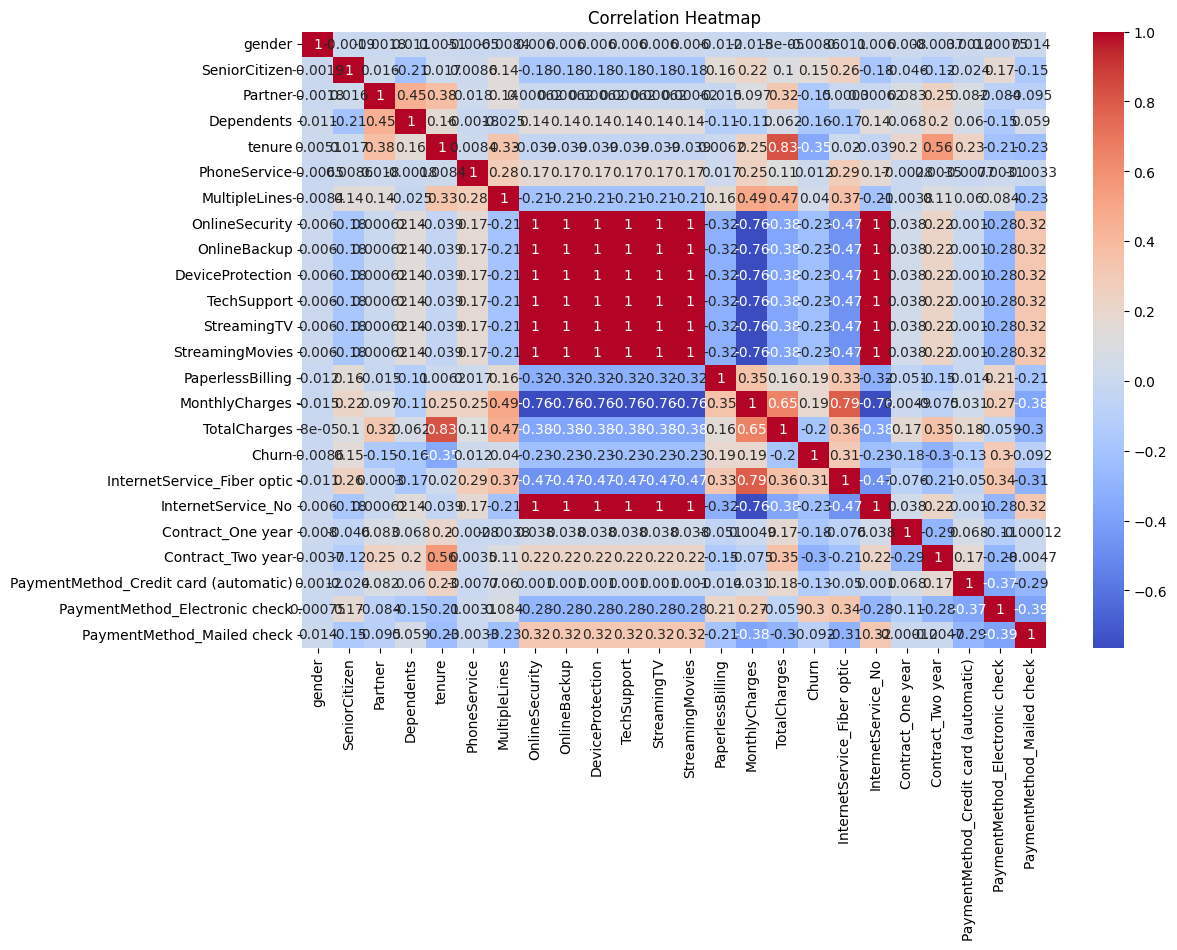

In [19]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', annot=True)

plt.title("Correlation Heatmap")
plt.show()

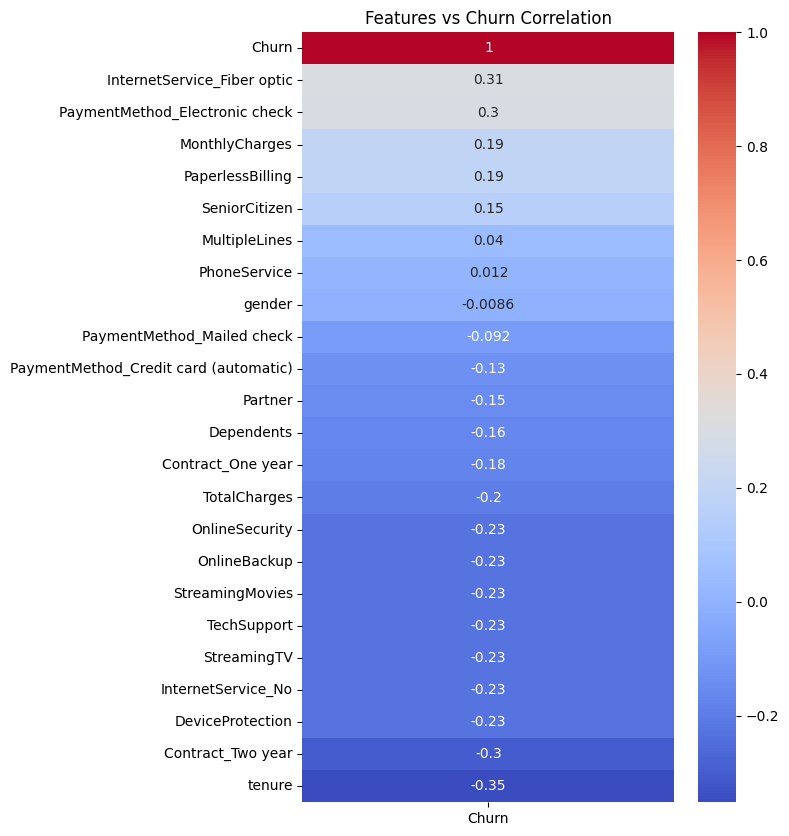

In [20]:

corr = df.corr()

plt.figure(figsize=(6, 10))
sns.heatmap(corr[['Churn']].sort_values(by='Churn', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Features vs Churn Correlation")
plt.show()

In [21]:

from scipy.stats import pearsonr
import pandas as pd

# Target column (ensure it's 0/1)
target = 'Churn'

# numerical features list (example churn dataset ke liye)
selected_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

correlations = {}

for feature in selected_features:
    corr, _ = pearsonr(df[feature], df[target])
    correlations[feature] = corr

correlation_df = pd.DataFrame(
    list(correlations.items()),
    columns=['Feature', 'Pearson Correlation']
)

correlation_df = correlation_df.sort_values(by='Pearson Correlation', ascending=False)
correlation_df

,Feature,Pearson Correlation
1,MonthlyCharges,0.193150
2,TotalCharges,-0.198323
0,tenure,-0.352229


In [22]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [23]:
cat_features = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'InternetService_Fiber optic',
    'InternetService_No',
    'Contract_One year',
    'Contract_Two year',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

In [24]:
from scipy.stats import chi2_contingency

alpha = 0.05

chi2_results = {}

for col in cat_features:

    contingency = pd.crosstab(df[col], df['Churn'])

    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    decision = (
        'Keep Feature'
        if p_val < alpha
        else 'Drop Feature'
    )

    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')

print(chi2_df)

                                      chi2_statistic   p_value      Decision
InternetService_Fiber optic               666.808021       0.0  Keep Feature
Contract_Two year                         641.828115       0.0  Keep Feature
PaymentMethod_Electronic check            640.557084       0.0  Keep Feature
StreamingTV                               364.519799       0.0  Keep Feature
OnlineSecurity                            364.519799       0.0  Keep Feature
OnlineBackup                              364.519799       0.0  Keep Feature
DeviceProtection                          364.519799       0.0  Keep Feature
TechSupport                               364.519799       0.0  Keep Feature
StreamingMovies                           364.519799       0.0  Keep Feature
InternetService_No                        364.519799       0.0  Keep Feature
PaperlessBilling                          258.277649       0.0  Keep Feature
Contract_One year                         221.710212       0.0  Keep Feature

In [25]:
df=df.drop(['PhoneService','gender'],axis=1)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   SeniorCitizen                          7043 non-null   int64
 1   Partner                                7043 non-null   int64
 2   Dependents                             7043 non-null   int64
 3   tenure                                 7043 non-null   int64
 4   MultipleLines                          7043 non-null   int64
 5   OnlineSecurity                         7043 non-null   int64
 6   OnlineBackup                           7043 non-null   int64
 7   DeviceProtection                       7043 non-null   int64
 8   TechSupport                            7043 non-null   int64
 9   StreamingTV                            7043 non-null   int64
 10  StreamingMovies                        7043 non-null   int64
 11  PaperlessBilling              

model training testing tuning learning. evaluation all

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM (RBF Kernel)": SVC(probability=True, random_state=42)
}

results = []

# Training and Evaluation
for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })

# Results Table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(results_df)

                 Model  Accuracy  F1 Score
4     SVM (RBF Kernel)    0.7921    0.5513
1                  KNN    0.7779    0.5444
0  Logistic Regression    0.7339    0.6130
3        Decision Tree    0.7253    0.4735
2          Naive Bayes    0.6423    0.5685


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[936  99]
 [194 180]]


In [29]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',   # you can change to 'f1' also
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Params (GridSearch):", grid.best_params_)

# Best model prediction
y_pred_grid = grid.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_grid))
print("F1 Score:", f1_score(y_test, y_pred_grid))

Best Params (GridSearch): {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy: 0.7892122072391767
F1 Score: 0.5612998522895125


In [31]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_dist = {
    'C': uniform(0.1, 10),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf']
}

random_search = RandomizedSearchCV(
    SVC(),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print("Best Params (RandomizedSearch):", random_search.best_params_)

# Best model prediction
y_pred_rand = random_search.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rand))
print("F1 Score:", f1_score(y_test, y_pred_rand))

Best Params (RandomizedSearch): {'C': np.float64(6.0241456886204245), 'gamma': np.float64(0.047450412719997725), 'kernel': 'rbf'}
Accuracy: 0.7913413768630234
F1 Score: 0.5650887573964497


In [32]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

bag = BaggingClassifier(
    estimator=LogisticRegression(max_iter=1000),
    n_estimators=20,
    random_state=42
)

bag.fit(X_train_scaled, y_train)

y_pred_bag = bag.predict(X_test_scaled)

print("F1 Score (Bagging):", f1_score(y_test, y_pred_bag))

F1 Score (Bagging): 0.5797101449275363


In [33]:

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)

print("F1 Score (Boosting):", f1_score(y_test, y_pred_gb))

F1 Score (Boosting): 0.5705705705705706


In [34]:

from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)

print("F1 Score (XGBoost):", f1_score(y_test, y_pred_xgb))

F1 Score (XGBoost): 0.5767045454545454


In [35]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train_scaled, y_train)

y_pred_stack = stack.predict(X_test_scaled)

print("F1 Score (Stacking):", f1_score(y_test, y_pred_stack))

F1 Score (Stacking): 0.5730994152046783


In [36]:

y_prob = model.predict_proba(X_test_scaled)[:, 1]

import numpy as np
from sklearn.metrics import f1_score

best_t, best_f1 = 0, 0

for t in np.arange(0.1, 0.9, 0.05):
    y_pred = (y_prob > t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t, best_f1)

0.25000000000000006 0.6041131105398457


In [37]:
import joblib
from sklearn.svm import SVC

# Best SVM model
best_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

# Train model
best_model.fit(X_train_scaled, y_train)

# Save model
joblib.dump(best_model, "best_svm_model.pkl")

# Save scaler bhi (VERY IMPORTANT)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Deployment stage